# Notebook to help with the GGOR tool

The case AAN_GZK is used as an exmaple

Always start with imports.

The mf6_bootstrap takes care that the following folders are added to sys.path

 • /Users/Theo/GRWMODELS/python/mf6lab/src
 • /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/src
 • /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/src

 A logger is set to allow following what happens when the code is run.

In [14]:
# %% --- imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
import logging
from mf6_bootstrap import activate # noqa: F401

import mf6_bootstrap
print(f"bootstrap folder: {mf6_bootstrap.__file__}")

activate(verbose=True) # noqa: RUF100

# --- Imports are not missing after activate(__file__)
# ruff: noqa: E402

from settings import props      # pyright: ignore[reportMissingImports]      
from timing import log_timed    # pyright: ignore[reportMissingImports]
from mf6tools import Dirs       # pyright: ignore[reportMissingImports]
import ggor_tools as ggt        # pyright: ignore[reportMissingImports]
from logging_setup import configure_logging # pyright: ignore[reportMissingImports]

# --- Setting up the logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
configure_logging()

bootstrap folder: /Users/Theo/GRWMODELS/python/bootstraps/mf6_bootstrap.py

[mf6_bootstrap] Activated
Caller: /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/notebooks/JUPYTER_FAKE_CALLER.py
Added paths:
  (none)


In [4]:
# --- Setting directory namespace
dirs = Dirs()
dirs.meteo = os.path.join(Path(dirs.proj).parent, 'data', 'meteo')
dirs.bofek = os.path.join(Path(dirs.proj).parent, 'data', 'bofek')

folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/data already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/doc already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/GIS already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/GWF already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/GWT already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/meteo already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/MP7 already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/images already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/notebooks already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/SIM already exists
folder /Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/cases/AAN_GZK/src already exist

In [18]:
# --- The case_name, same as the directory name for this case
case_name = Path(os.getcwd()).parent.parts[-1]
print(f"Case name is {case_name}")

Case name is AAN_GZK


There are two data sources that the GGOR builds on:

1. The tdata (everything dealing with time)
2. The parcel_data (everything pertaining to the parcels of the area)

They are read using the methods `get_tdata` and `get_parcel_data` in the `ggt` (`ggor_tools`) module.

Reading the tdata from file into a pandas DataFrame


In [5]:
tdata = ggt.get_tdata(dirs=dirs,  stn=240,
                start='20100101', end='20191231',
                folder=dirs.meteo)

# --- Set filename to store (to pickle) the time data for easy retrieval
tdata_file = os.path.join(dirs.data, 'tdata.pkl')
tdata.to_pickle(tdata_file)


File </Users/Theo/GRWMODELS/python/mf6lab/Projects/GGOR/data/meteo/weer240_20100101_20191231.txt> exists, download was skipped.


Show the tdata

In [13]:
tdata

,RH,EV24,summer,hyear,hand
dateUTC,,,,,
2010-01-01 08:00:00,0.000025,0.0003,False,2009,False
2010-01-02 08:00:00,0.000700,0.0002,False,2009,False
2010-01-03 08:00:00,0.000000,0.0003,False,2009,False
2010-01-04 08:00:00,0.000300,0.0002,False,2009,False
2010-01-05 08:00:00,0.000400,0.0002,False,2009,False
...,...,...,...,...,...
2019-12-27 08:00:00,0.000100,0.0004,False,2019,False
2019-12-28 08:00:00,0.000000,0.0003,False,2019,True
2019-12-29 08:00:00,0.000000,0.0002,False,2019,False


Some properties of the tdata DataFrame

1. Notice that RH is daily precipitation and EV24 is daily evapotranspiration according to Makkink.
2. These data come from KNMI.
3.  Also note that the values are in m/d.

In [9]:
tdata.columns, f"Aantal dagen in tdata {len(tdata)}",tdata[['RH', 'EV24']].mean()

(Index(['RH', 'EV24', 'summer', 'hyear', 'hand'], dtype='object'),
 'Aantal dagen in tdata 3652',
 RH      0.002250
 EV24    0.001693
 dtype: float64)

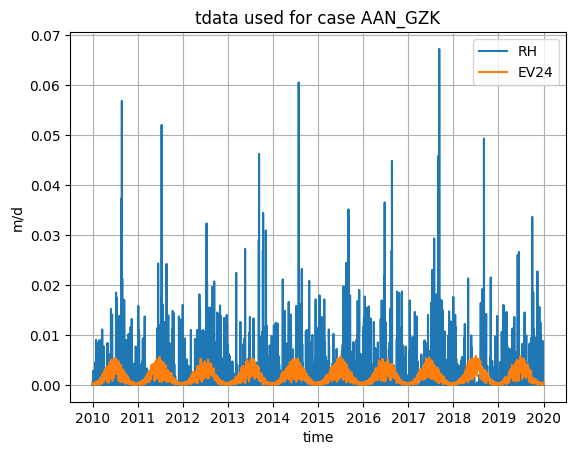

In [20]:
fig, ax = plt.subplots()
ax.set(title=f"tdata used for case {case_name}", xlabel='time', ylabel='m/d')
ax.plot(tdata.index, tdata.RH, label='RH')
ax.plot(tdata.index, tdata.EV24,label='EV24')
ax.grid(True)
ax.legend()

Get the parcel data

The parcel data are read from s shapefile into a geopandas GeoDataFrame

In [21]:
parcel_data = ggt.get_parcel_data(dirs=dirs, defaults=ggt.defaults, BMINMAX=(5, 250))


In [24]:
parcel_data.iloc[:5]

,OBJECTID_1,AANID,O_parcel,A_parcel,FID1,Oppervlak,Omtrek,X_Midden,Y_Midden,Gem_mAHN3,...,D2,wi_ditch,kh2,d_drain,co_ditch,b_ditch,ditch_omega1,ditch_omega2,wpp1,wpp2
0,1,1423175.0,970.129929,37941.090222,1,37941.090222,970.129929,148623.167406,477541.232016,-0.13,...,40.0,2.0,30.0,0,1.0,0.75,1.18,-0.0,2.266506,inf
1,2,1423286.0,930.203166,36684.617578,2,36684.617578,930.203166,148588.104936,477639.613493,-0.09,...,40.0,2.0,30.0,0,1.0,0.75,1.13,-0.0,2.425569,inf
2,3,1233347.0,728.996070,29397.595993,3,29397.595993,728.996070,148658.680492,478383.475072,-0.06,...,40.0,2.0,30.0,0,1.0,0.75,1.11,-0.0,3.304990,inf
3,4,1423215.0,368.006811,5327.104633,4,5327.104633,368.006811,147657.613658,476962.729346,0.15,...,40.0,2.0,30.0,0,1.0,0.75,0.86,-0.0,1.373281,inf
4,5,1233354.0,734.367045,25705.184226,5,25705.184226,734.367045,147640.560296,477579.991627,0.16,...,40.0,2.0,30.0,0,1.0,0.75,0.97,-0.0,1.301625,inf


There is a lot of information about the parcels in this GeoDataFrame

Here are the columns

In [29]:
parcel_data.columns, "-----", f"The number of parcels in {case_name} is {len(parcel_data)}"

(Index(['OBJECTID_1', 'AANID', 'O_parcel', 'A_parcel', 'FID1', 'Oppervlak',
        'Omtrek', 'X_Midden', 'Y_Midden', 'Gem_mAHN3', 'AHN', 'Gem_Kwel',
        'q_up', 'Gem_Phi2', 'phi', 'Gem_Cdek', 'c_CB', 'Gem_Ddek', 'D1',
        'h_summer', 'h_winter', 'Bodem', 'Grondsoort', 'LGN', 'LGN_CODE',
        'bofek', 'n_trench', 'geometry', 'b', 'kh', 'sy', 'kv', 'wi_ditch2',
        'ET_surfd', 'kv2', 'ci_ditch', 'D_CB', 'ET_exdp', 'c_drain',
        'wo_ditch2', 'wo_ditch', 'S2', 'd_ditch', 'd_trench', 'D2', 'wi_ditch',
        'kh2', 'd_drain', 'co_ditch', 'b_ditch', 'ditch_omega1', 'ditch_omega2',
        'wpp1', 'wpp2'],
       dtype='object'),
 '-----',
 'The number of parcels in AAN_GZK is 56')

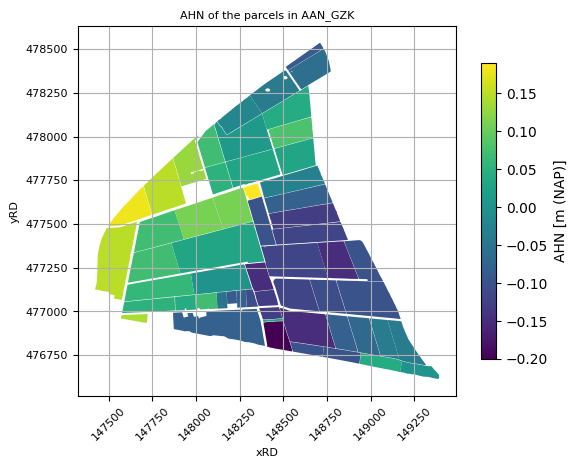

In [45]:
fig, ax = plt.subplots()

ax.set_title(f"AHN of the parcels in {case_name}", fontsize=8)
ax.set_xlabel("xRD", fontsize=8)
ax.set_ylabel("yRD", fontsize=8)

parcel_data.plot(column='AHN',
                 cmap='viridis',
                 ax=ax,
                 legend=True,
                 legend_kwds={"label": "AHN [m (NAP)]", "shrink": 0.8})

ax.tick_params(axis='both', labelsize=8)
ax.tick_params(axis='x', labelrotation=45)
ax.grid(True)



In [2]:
# mf_adapt sets the name of the Excel parameter workbook


#params_wbk = os.path.join(mf_adapt.HOME, mf_adapt.sim_name + '.xlsx')

use_models, use_packages  = mf6tools.get_models_and_packages_from_excel(
                                            mf_adapt.params_wbk, sheet_name='NAM')

model_dict = mf6tools.get_mf6_params_from_excel(
                                mf_adapt.params_wbk, sheet_name='SIM6')

if 'Gwf' in use_models:
    model_dict.update(mf6tools.get_mf6_params_from_excel(
                                mf_adapt.params_wbk, sheet_name='GWF6'))
if 'Gwt' in use_models:
    model_dict.update(mf6tools.get_mf6_params_from_excel(
                                mf_adapt.params_wbk, sheet_name='GWT6'))


NameError: name 'mf6tools' is not defined